# Pier-cap design, steel & section explorer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/joshstructure/D2MPDB/blob/main/Pier_Cap_Design_Optimizer.ipynb)

### C005 calculation · live reinforcement · bounded steel search

**Start here:** on GitHub, click **Open in Colab**, connect to a runtime, then **Runtime → Run all**. Locally, select the project's Python environment and choose **Run → Run All Cells**. Use the **live workbench** below for ordinary changes; you do not need to edit the supporting Python files.

This notebook ports the **324 engineering definitions** from the current C005 Blockpad module, including the corrected `Floor` expressions, and its **35-row pass register with 27 applicable D/C definitions**. It keeps a unit-aware calculation and independently rechecks retained search candidates.

The starting case is a **4 ft × 4 ft** cap, **four nominal 20 in piles at 5 ft centers**, and **18 ft 8 in** cap length. Initial trial steel is 8 #8 top and bottom, one #5 closed hoop at 8 in, and six #5 skin bars per side.

> **Current scope:** Service III and fatigue inputs are pending. Results are sectional checks and trial layouts. Anchorage, pile-head details, D-regions / strut-and-tie applicability, axial/biaxial actions, concurrency of force envelopes and final code/detail review are not completed by this notebook. A smaller D/C does not close these items.

**Workflow:** load a force case → inspect geometry and loads → change steel / watch the drawings → enumerate practical alternatives → apply one → review every check → export the selected case and a Blockpad review copy.


## 1 · Environment and case

The notebook, `pier_cap/` folder and `requirements-pier-cap.txt` travel together in the Git repository. On a new computer install the requirements once into a Python 3.12 environment. The local project environment is already prepared. Search and recalculation require **no AI calls** and do not contact an analysis service.

In VS Code, select **Python Environments → `.venv`** as the notebook kernel. Alternatively, launch JupyterLab with `Start-PierCap-Notebook.ps1`. In Colab, the first cell automatically downloads the `main` branch and installs `requirements-pier-cap-colab.txt`, then enables the interactive widgets. Push this notebook and its supporting files to GitHub together. A standard CPU runtime is sufficient. Each setup run refreshes an existing clean checkout from GitHub and clears cached calculation imports. Run all after refreshing so the controls use the updated code. Project edits or local-only commits stop the refresh with a recovery message; saved exports are left in place. The browser does not read files on your Windows computer unless you upload them. Download exports from the Colab Files panel before the temporary runtime ends.

If setup reports **Widget session restart required**, use **Runtime → Restart session**, then **Run all**. Colab uses its version 7 widget protocol. Setup pins the verified 7.7.1 package; if an earlier run installed version 8, changing the installed files does not replace the classes already in memory. Save an existing case before restarting. This is a session restart, not **Disconnect and delete runtime**.


In [1]:
# Optional first-time setup in a new environment (uncomment if needed):
# %pip install -r requirements-pier-cap.txt

from pathlib import Path
import importlib
import os
import subprocess
import sys

REPO_URL = "https://github.com/joshstructure/D2MPDB.git"
REPO_REF = "main"  # Keep this in sync with the Open in Colab badge.

try:
    from google.colab import output as colab_output
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    ROOT = Path("/content/D2MPDB")
    git_env = {**os.environ, "GIT_TERMINAL_PROMPT": "0"}

    def project_git(*args):
        return subprocess.run(
            ["git", "-C", str(ROOT), *args], check=True,
            env=git_env, text=True, capture_output=True,
        ).stdout.strip()

    if not ROOT.exists():
        try:
            subprocess.run(
                ["git", "clone", "--depth", "1", "--branch", REPO_REF,
                 "--single-branch", REPO_URL, str(ROOT)],
                check=True, env=git_env,
            )
        except subprocess.CalledProcessError as exc:
            raise RuntimeError(
                "Could not download the project. Push the notebook and supporting files "
                "to GitHub first. For a private repository, prepare an authenticated "
                "checkout at /content/D2MPDB before running this cell."
            ) from exc
    else:
        try:
            checkout_root = Path(project_git("rev-parse", "--show-toplevel")).resolve()
            branch = project_git("branch", "--show-current")
        except subprocess.CalledProcessError as exc:
            raise RuntimeError(
                "/content/D2MPDB is not a Git checkout. Save your case/exports, then "
                "use Runtime → Disconnect and delete runtime and Run all again."
            ) from exc
        if checkout_root != ROOT.resolve() or branch != REPO_REF:
            raise RuntimeError(
                f"The Colab checkout must be on {REPO_REF}. Save your case/exports, "
                "then use Runtime → Disconnect and delete runtime and Run all again."
            )
        if project_git("status", "--porcelain", "--untracked-files=no"):
            raise RuntimeError(
                "The Colab checkout has edited project files. Refresh stopped to preserve "
                "them. Download those edits and your case/exports before using Runtime → "
                "Disconnect and delete runtime, then Run all again."
            )
        previous_revision = project_git("rev-parse", "--short", "HEAD")
        try:
            project_git("fetch", "origin", REPO_REF)
            target_revision = project_git("rev-parse", "FETCH_HEAD")
            # Reject local-only/divergent commits; never reset or overwrite them.
            project_git("merge-base", "--is-ancestor", "HEAD", target_revision)
            project_git("merge", "--ff-only", target_revision)
        except subprocess.CalledProcessError as exc:
            raise RuntimeError(
                "Could not refresh the Colab supporting files. Check GitHub access and "
                "that all project changes were pushed. Local commits or files that block "
                "the update are preserved. Save your case/exports before starting a fresh "
                "runtime. Setup stopped instead of using stale calculations."
            ) from exc
        refreshed_revision = project_git("rev-parse", "--short", "HEAD")
        print(f"Supporting files: {previous_revision} → {refreshed_revision}")

    revision = project_git("rev-parse", "--short", "HEAD")
    requirements = ROOT / "requirements-pier-cap-colab.txt"
    if not (ROOT / "pier_cap").is_dir() or not requirements.is_file():
        raise RuntimeError("Push pier_cap/ and requirements-pier-cap-colab.txt with the notebook, then rerun setup.")
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-r", str(requirements)], check=True)
    # Pip does not replace classes already in memory. Require Colab's
    # tested widget protocol and a session matching the installed files.
    import ipywidgets as widget_runtime
    from importlib.metadata import version as installed_version
    loaded_widgets = widget_runtime.__version__
    installed_widgets = installed_version("ipywidgets")
    if loaded_widgets != installed_widgets or loaded_widgets != "7.7.1":
        raise RuntimeError(
            f"Widget session restart required: Python loaded ipywidgets {loaded_widgets}, "
            f"but {installed_widgets} is installed. Use Runtime → Restart session, "
            "then reload this browser page and Run all. Do not delete the runtime. Save any existing case before "
            "restarting. Upload/search controls will not be created in this mixed state."
        )
    import plotly as plot_runtime
    if plot_runtime.__version__ != "5.24.1" or installed_version("plotly") != "5.24.1":
        raise RuntimeError(
            "Chart session restart required. Save your case, use Runtime → Restart session, "
            "reload this browser page, then Run all. Colab needs Plotly 5.24.1 for live chart widgets."
        )
    # Colab may import widgets before its kernel exists; register handlers now.
    widget_runtime.register_comm_target(get_ipython().kernel)
    colab_output.enable_custom_widget_manager()
    os.chdir(ROOT)
    # A previous run (even a failed import) may have cached the old package.
    for module_name in list(sys.modules):
        if module_name == "pier_cap" or module_name.startswith("pier_cap."):
            del sys.modules[module_name]
    importlib.invalidate_caches()
else:
    ROOT = Path.cwd()
    if not (ROOT / "pier_cap").is_dir():
        raise RuntimeError("Open this notebook from the D2MPDB repository root; keep the pier_cap folder beside it.")
if str(ROOT) in sys.path:
    sys.path.remove(str(ROOT))
sys.path.insert(0, str(ROOT))

# Explain a partially published update before importing the notebook API.
optimizer_module = importlib.import_module("pier_cap.optimizer")
required_search_api = ("SearchConfig", "search", "candidate_case", "filter_candidates", "candidate_dc", "governing_check")
missing_search_api = [name for name in required_search_api if not hasattr(optimizer_module, name)]
if missing_search_api:
    raise RuntimeError(
        "The notebook and supporting calculation files are different versions. "
        f"Missing: {', '.join(missing_search_api)}. Push the notebook and the entire "
        "pier_cap/ folder together, then reopen the notebook and Run all."
    )

from IPython.display import display, HTML
import matplotlib.pyplot as plt
from pier_cap.model import default_case, evaluate, set_inputs, formula_trace, DEFINITIONS
try:
    from pier_cap.fbmp import import_fbmp_xml
    from pier_cap.widgets import CapNotebook
except ImportError as exc:
    raise RuntimeError("The XML importer files are missing or out of date. Push this notebook and the entire pier_cap/ folder together, then reopen and Run all.") from exc
from pier_cap.optimizer import SearchConfig, search, candidate_case, filter_candidates, candidate_dc, governing_check
from pier_cap.io import load_case, write_case, import_workbooks, export_bundle, export_blockpad
from pier_cap.visuals import snapshot, checks_html
try:
    from pier_cap.sections import SectionGrid, CostRates, run_section_study, section_rows
    from pier_cap.section_widgets import SectionStudy
    from pier_cap.section_visuals import section_snapshot
except ImportError as exc:
    raise RuntimeError("The section-study files are missing or out of date. Push this notebook and the entire pier_cap/ folder together, then reopen from GitHub and Run all.") from exc

if IN_COLAB:
    print(f"Colab ready · {REPO_REF} · supporting calculation revision {revision}")

case = default_case()  # Or: load_case("path/to/selected_case.json")
baseline = evaluate(case)
print(baseline.status)
print(f"Strength D/C: {governing_check(baseline, 'strength').ratio:.4f} | "
      f"all-check utilization (includes detailing): {baseline.max_dc:.4f} | "
      f"cap length: {baseline.value('L_cap') / 12:.3f} ft")

PROVISIONAL — SERVICE III / FATIGUE INPUTS PENDING
Strength D/C: 0.8317 | all-check utilization (includes detailing): 0.9851 | cap length: 18.667 ft


## 2 · Starting case snapshot

This saved output also appears in GitHub's notebook preview. The **live workbench in the next section** recalculates when its inputs change; this starting snapshot remains a reference until this cell is rerun.

The **12 in nominal extension** beyond the outside pile face is the adopted **9 in actual clearance + 3 in pile-location tolerance** at the starting pile size. It is not a universal FDOT fixed end dimension. The source calculation uses `min(3 in, pile width / 6)` for tolerance and permits additional end allowance. Confirm required reinforcement development, pile-head detailing and the governing project criteria before finalizing.

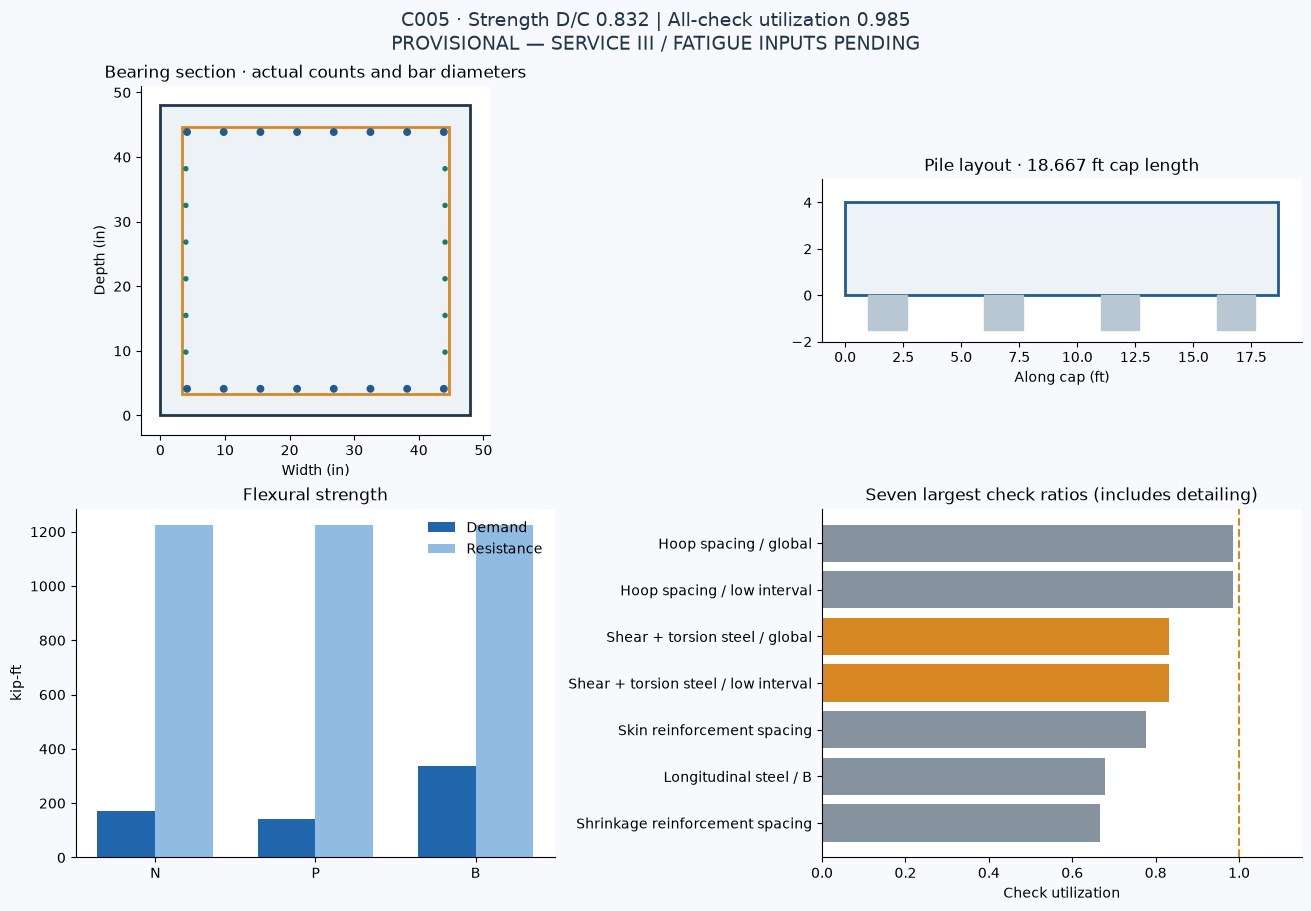

In [2]:
starting_figure = snapshot(baseline)
display(starting_figure)
plt.close(starting_figure)

## 3 · Live workbench

**Steel** opens first. Its accordions group top bars, bottom bars, hoops/skin and optional detail inputs. Other tabs hold geometry, loads, pending actions and material factors. Press Enter or leave a number field to apply it.

- **Live cage:** circles have the entered count, diameter and row position. Pile layout and hoop strips redraw too.
- **Plots:** flexure, steel stress, shear, combined shear/torsion steel and available D/C comparisons.
- **Pass / D/C register:** original checks and ratio bases. `PENDING`, `N/A` and failures stay explicit.
- **Equation trace:** auditable source expressions and unit-bearing results.
- **Search practical steel:** run the allowed sizes/counts/spacings, then browse **all passing layouts** with **Page / Previous / Next** and **Per page**. Set **Max D/C** to `0.90` and choose **All available checks** or **Strength checks only**. Filtering and ranking reuse the search immediately. **Apply selected layout** loads the candidate ID shown in the dropdown.
- **Export current case + checks:** saves a new bundle in `exports/`; load its `selected_case.json` next time.

Changing the pile configuration, cap dimensions or end allowances flags **REIMPORT FORCES**. It does not rerun FB-MultiPier. Load a matching JSON bundle, or enter the new forces and record the analyzed geometry with its analysis ID. Merely changing reinforcement does not change the analysis provenance.

The trial clear-spacing input is an additional geometric screen, not a substitute for checking code spacing and aggregate requirements. U legs and multiple loops retain unresolved-topology notices because their full positions are not supplied by C005.

The search now defaults to **Strength checks only**. The live summary shows strength D/C and all-check utilization separately, with their controlling checks. Under **Plots**, the hoop-spacing table separates along-cap spacing from across-cap leg spacing.

For a fresh analysis, use **Upload FBMP XML** at the top of the workbench. Review the detected section, piles, materials and force envelopes, then **Apply XML inputs**. The cage and checks update immediately; rerun your search for the new loads.

A yellow **PREVIEW READY — NOT APPLIED** message means the XML was read but the active loads have not changed. After Apply, look for the green **LOADS IMPORTED SUCCESSFULLY** receipt and the **ACTIVE FORCE SOURCE** summary. Import errors appear beside the upload control. Rerun a search with its button; rerunning this workbench cell also preserves the active case in the same runtime. Use **Reset starting case** to intentionally return to the original example. Save a case JSON before ending or deleting the runtime.

In [3]:
# Preserve imported inputs if this cell (or Run all) is run again in this runtime.
from copy import deepcopy
_previous_app = globals().get("app")
_active_case = deepcopy(_previous_app.case) if _previous_app is not None else case
_previous_receipt = deepcopy(getattr(_previous_app, "import_receipt", None))
app = CapNotebook(_active_case, export_root=ROOT / "exports")
if _previous_app is not None:
    for _name, _control in _previous_app.search_lists.items():
        app.search_lists[_name].value = _control.value
    for _name in ("limit", "dc_limit", "dc_scope", "objective", "page_size"):
        getattr(app, _name).value = getattr(_previous_app, _name).value
if _previous_receipt is not None:
    app.import_receipt = _previous_receipt
    app.refresh()
# A previously displayed section study must follow this new workbench instance.
_existing_study = globals().get("section_app")
if _existing_study is not None:
    if hasattr(_existing_study, "rebind"):
        _existing_study.rebind(app)
    else:
        _existing_study.close()
        section_app = None
        print("Rerun the section-study cell to connect it to these inputs.")
if _previous_app is not None:
    if hasattr(_previous_app, "close"):
        _previous_app.close()
    else:
        for _figure in _previous_app.figures:
            _figure.close()
        _previous_app.ui.close()
app.display();

Run this cell in Jupyter or Colab to load the live calculator, all-candidate browser and D/C filters.

## 4 · Reproducible search example

This cell demonstrates the same search without UI interaction. It runs **1,944 combinations** for the starting case and leaves the live inputs unchanged. A search in the workbench uses its current inputs instead.

The search family has one continuous top row, one continuous bottom row shared by pile/bearing regions, one hoop, uniform hoop spacing and evenly spaced skin bars. More complex arrangements can be entered manually in the workbench.

**Least steel** minimizes a gross weight estimate. **Simplest cage** minimizes longitudinal bar count plus five times the number of distinct bar sizes, then weight. **Largest margin** minimizes the D/C in the selected filter scope, then weight. These are explicit ranking choices, not a claim of a global optimum over all possible detailing. The result states whether every listed combination was evaluated. Returned candidates pass the available numerical checks and cage screen, with pending checks retained.

Weight uses full cap lengths for top/skin and the largest bottom cage, plus uniform hoops at the tighter entered spacing. **Hooks, laps, anchorage, bends and waste are excluded.**

**All passing candidates are retained.** The workbench initially displays 20 per page; use its page controls to select later candidates. These are reinforcement alternatives for the same force case, not different load combinations. IDs remain fixed within each search. The plot shows all filter matches and exports include all pages.

**Margin target:** `All available checks` includes spacing, minimum steel, strain and service ratios. `Strength checks only` targets flexure, shear, combined shear/torsion steel and longitudinal steel; every other available check must still pass. The table shows both ratios. With the starting inputs/default choices, an all-check target of 0.90 finds **zero** layouts because transverse hoop-leg spacing governs at about 0.982 or higher. A strength-only target of 0.90 finds **210** layouts. Pending checks remain pending.

The example below previews the first ten strength-filter matches; the full list is available through `matching_ids` and the workbench's pages.

**Why nothing was below 0.97 in the all-check view:** the single outer hoop spans nearly the full cap width. With a #6 hoop, `(48 − 2 × 3 − 0.75) / 42 = 0.98214` is the across-cap spacing utilization. More main bars or closer hoops along the cap do not shorten that across-cap span. This is a detailing ratio, not the strength D/C. The default list contains **306 strength matches at 0.97**, **210 at 0.90**, and reaches a lowest strength D/C of about **0.547**. All other available checks must still pass; Service III/fatigue remain pending. See [the focused ratio review](DC_RATIO_REVIEW.md).

In [4]:
example_search = search(case, SearchConfig())
print(f"Evaluated {example_search.evaluated:,} / {example_search.total:,}; "
      f"retained ALL {len(example_search.candidates):,} passing layouts.")
print(f"Exhaustive within the listed choices: {example_search.exhaustive}; "
      f"elapsed {example_search.elapsed:.2f} s")

TARGET_DC = 0.90
FILTER_SCOPE = "strength"  # "all" applies the target to every available numerical check.
matching_ids = filter_candidates(example_search, max_dc=TARGET_DC, scope=FILTER_SCOPE)
print(f"{len(matching_ids):,} layouts meet {FILTER_SCOPE} D/C <= {TARGET_DC:.2f}. "
      "Previewing the first 10 below; the workbench lets you page through every match.")
print(f"All-check matches at the same target: {len(filter_candidates(example_search, TARGET_DC, 'all'))}")

import html
rows = "".join(
    f"<tr><td>{rank}</td><td>#{index+1}</td><td>{html.escape(c.label)}</td>"
    f"<td>{c.weight_lb:,.0f}</td><td>{candidate_dc(c, FILTER_SCOPE):.4f}</td><td>{c.max_dc:.4f}</td></tr>"
    for rank, (index, c) in enumerate(
        ((i, example_search.candidates[i]) for i in matching_ids[:10]), 1
    )
)
display(HTML('<table><tr><th>Filtered rank</th><th>Candidate ID</th><th>Trial layout</th>'
             '<th>Gross steel, lb</th><th>Filter D/C</th><th>All-check utilization</th></tr>' + rows + '</table>'))
if matching_ids:
    chosen_index = matching_ids[0]  # Any index from matching_ids can be used here.
    trial = evaluate(candidate_case(example_search, chosen_index))
    print("Leading matching candidate status:", trial.status)
    print("Baseline gross steel:", round(baseline.weight_lb), "lb; candidate:", round(trial.weight_lb), "lb")
# To send the chosen case to the workbench, uncomment:
# app.load(candidate_case(example_search, chosen_index))

Evaluated 1,944 / 1,944; retained ALL 324 passing layouts.
Exhaustive within the listed choices: True; elapsed 4.80 s
210 layouts meet strength D/C <= 0.90. Previewing the first 10 below; the workbench lets you page through every match.
All-check matches at the same target: 0


Filtered rank,Candidate ID,Trial layout,"Gross steel, lb",Filter D/C,All-check utilization
1,#27,6 #7 top / 8 #7 bottom · #5 @ 8 in · 6 #5/side,"1,192",0.8558,0.9851
2,#34,8 #7 top / 8 #7 bottom · #5 @ 8 in · 7 #4/side,"1,210",0.8929,0.9851
3,#38,6 #8 top / 6 #8 bottom · #5 @ 8 in · 5 #5/side,"1,221",0.8805,0.9851
4,#40,8 #7 top / 8 #7 bottom · #5 @ 8 in · 5 #5/side,"1,229",0.8718,0.9851
5,#41,6 #7 top / 8 #7 bottom · #5 @ 8 in · 7 #5/side,"1,231",0.8317,0.9851
6,#49,6 #7 top / 8 #7 bottom · #6 @ 10 in · 6 #5/side,"1,243",0.8563,0.9821
7,#53,6 #8 top / 6 #8 bottom · #5 @ 8 in · 6 #5/side,"1,260",0.8391,0.9851
8,#54,8 #7 top / 8 #7 bottom · #6 @ 10 in · 7 #4/side,"1,261",0.8937,0.9821
9,#57,8 #7 top / 8 #7 bottom · #5 @ 8 in · 6 #5/side,"1,268",0.8317,0.9851
10,#59,6 #8 top / 6 #8 bottom · #6 @ 10 in · 5 #5/side,"1,273",0.8813,0.9821


Leading matching candidate status: PROVISIONAL — SERVICE III / FATIGUE INPUTS PENDING
Baseline gross steel: 1461 lb; candidate: 1192 lb


## 5 · Search cap width, depth and reinforcement

**Start with the interactive study below.** It uses the reinforcement choices selected in the main workbench and starts with widths **44–52 in by 4 in**, depths **36–60 in by 6 in**, and strength D/C **≤ 0.90**. Edit the ranges and optional project minimums, then press **Run section study**.

- **Sensitivity · fixed forces** holds the current force inputs constant. It explores sectional response only; cap self-weight, stiffness and redistributed analysis forces are not recomputed. The original force-source geometry stays attached to every selected/exported case.
- **Only analysis-matched cases** uses the current source case at its own section plus actual analysis case JSON files you upload. Missing or conflicting analyses are visible; the study does not substitute old forces. Reuse over trial reinforcement also depends on the stiffness assumptions of your analysis model.
- **Click a heatmap cell or ranked cost bar** to select its section. Every cage meeting the strength target is available in the cage selector. Live drawings, capacity plots and the check register follow your selection. **Load selected case into calculator** transfers it to the main workbench; a changed fixed-force section stays flagged for reanalysis.
- **Refine around this section** narrows the bounds and halves both steps. Press Run again to evaluate that finer grid. Exact repeated calculations are cached in this runtime. Target and cost changes update the view without a new search.
- Each heatmap cell shows **concrete volume and steel weight together** for its lightest matching cage. Switch **Cell labels** to see separate concrete/steel/forms costs. Hover for the full breakdown and material/cost differences from the cheapest explored section. Dense grids use hover labels to keep the map readable.
- Enable **Use my comparison unit rates** and enter your rates. The map switches to **Cost above cheapest (%)**, with zero marking the lowest estimated cost. The summary names that section; the stacked cost bars and expandable table rank alternatives by concrete + steel + forms cost. **Select cheapest section + cage** selects its lightest matching cage for review. Zero-rate items are explicitly excluded. The material tradeoff plot remains in an expandable panel.
- Changing prices does not repeat the search. A heavier selected cage keeps its own cost/premium summary; the map always uses the lightest target-matching cage at each section.

The width screen uses the pile width plus twice the adopted nominal edge allowance—**44 in for the starting inputs**—and any larger project minimum you enter. The single-outer-hoop family remains a restriction: wider sections may need additional hoop arrangements that are not modeled by this search. Blank map points explain missing analysis, geometry screens, failed cages or search-budget limits; they are not silently omitted.

**Export section study** writes every geometry summary, every retained cage, study settings and analysis records, a list of sections needing analysis, and the selected case JSON. Pending Service III/fatigue and the source calculation scope remain explicit. See [the section-study guide](SECTION_STUDY.md).

**Confirm the inputs before searching:** the **FORCE SOURCE FOR SECTION STUDY** panel at the top lists the active source, analyzed dimensions and current M/V/T inputs. Applying new loads clears old study plots and cages. Press **Run section study** to rebuild them. Adding a JSON to the optional analysis library does not replace the main calculator loads in fixed-force mode.

In [5]:
# Dispose of the earlier study if this cell is rerun.
if globals().get("section_app") is not None:
    section_app.close()
section_app = SectionStudy(app)
section_app.display();

Run this cell in Jupyter or Colab to load the live calculator, all-candidate browser and D/C filters.

### Saved coarse-grid example

The next cell runs a **nine-section fixed-force demonstration** using the supplied starting case and default 1,944 steel choices. Its static figure appears on GitHub. It does not replace the main calculator's case or run FB-MultiPier. The larger interactive ranges above are a separate study; this example warms the calculation cache for overlapping points.

Set `RUN_SECTION_EXAMPLE = False` to skip this demonstration on later Run-all sessions.

The saved example compares material quantities without assuming prices. Use the live study above to see cost rankings at your entered rates.

FIXED-FORCE SENSITIVITY — no new analysis forces
6 / 9 sections have target-matching cages; 17,496 candidate evaluations; 41.1 s.


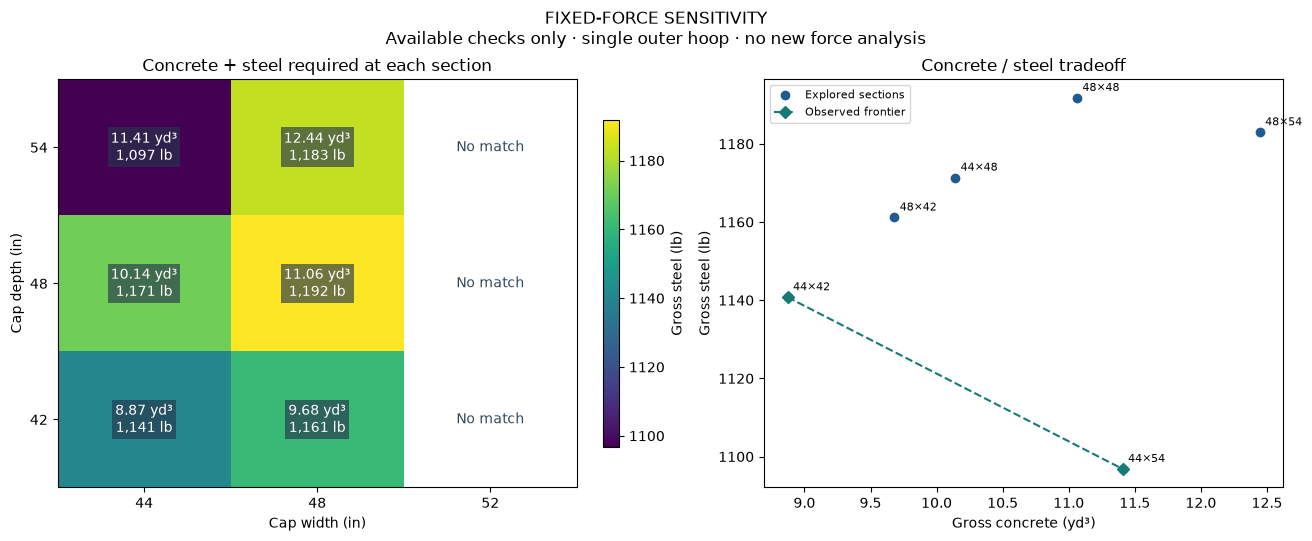

In [6]:
RUN_SECTION_EXAMPLE = True
if RUN_SECTION_EXAMPLE:
    geometry_example = run_section_study(
        case,
        SectionGrid(widths=(44, 48, 52), depths=(42, 48, 54), force_mode="fixed"),
        SearchConfig(), cache=section_app.cache,
    )
    geometry_rows = section_rows(geometry_example, target=0.90)
    print("FIXED-FORCE SENSITIVITY — no new analysis forces")
    print(f"{sum(bool(r['matches']) for r in geometry_rows)} / {len(geometry_rows)} sections have target-matching cages; "
          f"{geometry_example.evaluated:,} candidate evaluations; {geometry_example.elapsed:.1f} s.")
    geometry_figure = section_snapshot(geometry_example, geometry_rows)
    display(geometry_figure)
    plt.close(geometry_figure)
    # Programmatic export, if desired:
    # from pier_cap.sections import export_section_study
    # export_section_study(geometry_example, ROOT / "exports", target=0.90)

## 6 · New loads from one XML

**Fastest workflow:** in the workbench, click **Upload FBMP XML**, in Colab click **Choose Files** when it appears, select the solved FB-MultiPier XML, review the proposed changes, and click **Apply XML inputs**. Then rerun the steel or section search. The upload works in local Jupyter and Colab. No three-workbook conversion is needed for the supported format.

The reader supports the reviewed **6.1.0 static English-unit pile-bent** layout: one straight horizontal cap, uniform rectangular section, identical round/square piles, equal spacing and symmetric ends. It checks the actual cap mesh, unit labels, combination completeness, raw I/J force signs and the separate cap summary before enabling Apply. Geometry and cap materials come from the XML; your trial reinforcement and covers are retained. A case edit after preview requires **Refresh preview**.

The preview lists current and proposed inputs, plus governing combinations and member locations. Pile-positive moments include recovered pile faces; bearing/span-positive moments use the full-cap positive envelope, including interior peaks. The low-shear input conservatively takes global shear. Service III/fatigue reset to pending. Strength III is not Service III. See **FBMP_IMPORT.md** for the verified mapping and limitations. Native `.out` parsing is not implemented.

Use **Export current case + checks** to save the complete case and import audit, then **Load case JSON** to reuse it later. Source geometry is retained so later dimensional edits continue to flag stale forces.

The optional three-workbook converter remains below for existing `Max_PierCap_*_Design` exports. Use all three from one analysis run; their section dimensions and end allowances remain user-declared. For a programmatic XML preview: `proposed = import_fbmp_xml("your_file.XML", base=app.case)`; inspect it, then `app.load(proposed)`.

**Success confirmation:** selecting a file first shows **PREVIEW READY — NOT APPLIED**. Applying it shows **LOADS IMPORTED SUCCESSFULLY**, the file name and time, and the active source/loads beside it. A file-count badge alone is not proof of import. The separate **Run section study** button evaluates your new forces; old plots are cleared. Rerunning notebook cells preserves the active case in the same runtime, but ending/deleting the runtime still requires reloading a saved case.

Colab uses its native file transfer; the file chooser disappears when transfer finishes. A cancelled upload or invalid file produces an explicit message. If upgrading an older session, save your case, restart the session, reload the browser page and Run all to clear stale widget views.


In [7]:
# Optional conversion: edit the folder and set CONVERT_WORKBOOKS = True.
CONVERT_WORKBOOKS = False
if CONVERT_WORKBOOKS:
    source_folder = Path.home() / "Downloads"
    converted = import_workbooks(
        source_folder / "Pier_MinTip_Max_PierCap_Moment_Design.xlsx",
        source_folder / "Pier_MinTip_Max_PierCap_Shear_Design.xlsx",
        source_folder / "Pier_MinTip_Max_PierCap_Torsion_Design.xlsx",
        base=app.case,
        analysis_id="Enter the actual FB-MultiPier run ID",
        # For the supplied four-pile starting model only:
        low_interval_labels=["Pil 2 RCL", "Pil 2 RF", "Pil 3 LF", "Pil 3 LCL"],
    )
    app.load(converted)
    print("Converted case loaded. Review dimensions and source ID, then export its JSON.")

## 7 · Detailed calculation and review handoff

The live workbench is the main calculator. This independent cell prints the current workbench's full pass register when rerun; it does not silently follow subsequent widget edits. The remaining trace lists every source definition, with callable helper functions identified.

The notebook preserves the source method: rectangular flexure/strain and minimum steel; transformed cracked-section service stresses and crack-control spacing; fatigue stress range; sectional shear, minimum steel and spacing; torsion/combined steel and longitudinal tension; skin/shrinkage and mass-concrete screening. Source formulas and constants remain visible for engineering review rather than being replaced by an opaque optimizer.

In [8]:
current = evaluate(app.case)
display(HTML(checks_html(current)))
trace = {r["name"]: r for r in formula_trace(current)}
detail_rows = "".join(
    "<tr><td>" + html.escape(d["formula"]) + "</td><td>" +
    html.escape(str(trace.get(d["name"], {}).get("value", "Helper function"))) + "</td><td>" +
    html.escape(d["caption"]) + "</td></tr>" for d in DEFINITIONS
)
display(HTML('<details><summary><b>All 324 source definitions and current results</b></summary>'
             '<table><tr><th>Equation</th><th>Result</th><th>Note</th></tr>' + detail_rows + '</table></details>'))

Check,Status,Check ratio,Ratio basis
Pile layout validity,✓ PASS,N/A,"Minimum spacing, edge clearance and integer pile count; see geometry checks."
Load input validity,✓ PASS,N/A,"Required moment, shear and torque magnitudes must be nonnegative."
Bar size validity,✓ PASS,N/A,Supported US bar numbers.
Bar / loop count validity,✓ PASS,N/A,Nonnegative integer counts and required minimum counts.
Section input validity,✓ PASS,N/A,"Geometry, materials, factors, covers and spacings must be valid."
Flexural strength — N,✓ PASS,0.138,Factored moment / factored flexural resistance.
Minimum flexural steel — N,✓ PASS,0.184,Minimum required moment resistance / provided resistance.
Tension strain screen — N,✓ PASS,0.087,Required minimum strain (0.005) / calculated tension strain.
Service I — N,✓ PASS,0.142,Larger of steel stress / limit and actual bar spacing / allowable spacing.
Longitudinal steel — N,✓ PASS,0.572,Larger of total tension / yield resistance and extra area required / effective skin area.


Equation,Result,Note
b = BridgeGeometry_2Beam.PierCap_width to in,48.00000 in,Cap cross-section width; live journal geometry.
h = BridgeGeometry_2Beam.PierCap_ht to in,48.00000 in,Cap depth; live 4 ft input governs the older 6 ft prose.
C_t = PedBridge.Cap_cover to in,3.00000 in,Clear top cover to the outside of the hoop.
C_b = PedBridge.Cap_cover to in,3.00000 in,Clear bottom cover to the outside of the hoop.
C_s = PedBridge.Cap_cover to in,3.00000 in,Clear side cover to the outside of the hoop.
N_pile = 4,4.00000,Current Excel configuration; total piles in one equally spaced row.
S_pile = 5 ft,5.00000 ft,Current Excel center-to-center pile spacing.
D_pile = 20 in,20.00000 in,Nominal pile width along the cap; Excel faces are rounded to 0.83 ft from centers.
E_clear = 9 in,9.00000 in,Minimum actual pile-face edge clearance adopted from the FHWA discussion of LRFD 10.7.1.2.
"Tol_pile = Min(3 in, D_pile/6) to in",3.00000 in,FDOT specified pile location tolerance; nominal end extension includes this allowance.


### Export to Blockpad and GitHub

Use the workbench's export buttons. A bundle includes `selected_case.json`, `checks.csv`, `formula_trace.json`, `blockpad_inputs.txt`, and `review.json`; searches also include `alternatives.csv` (every passing layout) and `filtered_alternatives.csv` (every current filter match, across all pages). The target and scope are recorded in `review.json`. Existing exports are never overwritten.

For a **Blockpad review copy**, enter the path to your existing **C005 Live Design** journal. The exporter replaces only C005 inputs and analysis-source comparisons in a new file, adds a handoff note, and preserves other project sections. Open and recalculate the copy in native Blockpad. The notebook does not mark the broader project finalized. Earlier narrative examples in the journal may still describe the starting model and must be reconciled during final review.

The `.venv/`, generated `exports/`, caches and runtime files are ignored by Git. Commit/push the notebook plus `pier_cap/`, requirements, launcher, README and tests together. Saved static outputs are included for GitHub viewing; **interactive widgets require a running Jupyter kernel**.

**Validation:** `python -m unittest discover -s tests -v`. See `README.md` for launch and portability details, `DESIGN_SCOPE.md` for assumptions, and `pier_cap/data/provenance.json` for the source calculation hash.